In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Banglore

In [1]:
df = pd.read_csv(r"C:\Users\aksha\Banglore_Cars24.csv")

In [2]:
df.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Tata TIGOR,Tata,2021,"36,206 km",Petrol,Manual,"EMI ₹10,060/m*",₹5.70 lakh
1,Maruti Wagon R 1.0,Maruti,2017,"43,965 km",Petrol,Auto,"EMI ₹7,484/m*",₹3.83 lakh
2,Renault Kwid,Renault,2017,"45,145 km",Petrol,Manual,"EMI ₹5,645/m*",₹2.89 lakh
3,Maruti Wagon R 1.0,Maruti,2017,"49,218 km",Petrol,Auto,"EMI ₹7,147/m*",₹3.66 lakh
4,Volkswagen Ameo,Volkswagen,2016,"67,291 km",Petrol,Manual,"EMI ₹9,518/m*",₹4.28 lakh


In [3]:
df.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
2377,Hyundai Grand i10,Hyundai,2015,"68,680 km",Petrol,Manual,"EMI ₹9,164/m*",₹3.48 lakh
2378,KIA SONET,KIA,2021,"55,527 km",Diesel,Auto,"EMI ₹15,239/m*",₹8.90 lakh
2379,KIA SONET,KIA,2023,"25,105 km",Diesel,Manual,"EMI ₹19,828/m*",₹11.58 lakh
2380,KIA SONET,KIA,2023,"12,979 km",Petrol,Manual,"EMI ₹16,352/m*",₹9.55 lakh
2381,KIA SELTOS,KIA,2019,"39,597 km",Petrol,Auto,"EMI ₹19,263/m*",₹11.25 lakh


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2382 entries, 0 to 2381
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             2382 non-null   object
 1   Company              2382 non-null   object
 2   Year of Manufacture  2382 non-null   int64 
 3   Distance Driven      2382 non-null   object
 4   Fuel Type            2382 non-null   object
 5   Gear Type            2382 non-null   object
 6   EMI                  2382 non-null   object
 7   Price                2382 non-null   object
dtypes: int64(1), object(7)
memory usage: 149.0+ KB


In [5]:
df.describe()

,Year of Manufacture
count,2382.000000
mean,2017.432830
std,3.702092
min,2006.000000
25%,2015.000000
50%,2017.000000
75%,2021.000000
max,2025.000000


In [6]:
df.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.duplicated().sum()

0

In [9]:
df = df.drop_duplicates()

In [10]:
df.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [12]:
df['Price'] = df['Price'].str.replace('₹','').str.replace(',','').str.strip()

df.loc[df['Price'].str.contains('lakh'), 'Price'] = (
    df.loc[df['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','')
    .astype(float) * 100000
)

df['Price'] = df['Price'].astype(float)


In [28]:
df['EMI'] = (
    df['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [18]:
df["Distance Driven"] = (
    df["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [20]:
df["Year of Manufacture	"] = df["Year of Manufacture"].astype(int)

In [31]:
df['Car Name']=df['Car Name'].astype("string")
df['Company']=df['Company'].astype("string")
df['Fuel Type']=df['Fuel Type'].astype("string")
df['Gear Type']=df['Gear Type'].astype("string")

In [33]:
current_year = datetime.now().year
df['Car Age'] = current_year - df['Year of Manufacture']

In [39]:
df["City"] = "Bangalore"

In [40]:
df.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2021,36206,Petrol,Manual,10060,570000.0,5,Bangalore
1,Maruti Wagon R 1.0,Maruti,2017,43965,Petrol,Auto,7484,383000.0,9,Bangalore
2,Renault Kwid,Renault,2017,45145,Petrol,Manual,5645,289000.0,9,Bangalore
3,Maruti Wagon R 1.0,Maruti,2017,49218,Petrol,Auto,7147,366000.0,9,Bangalore
4,Volkswagen Ameo,Volkswagen,2016,67291,Petrol,Manual,9518,428000.0,10,Bangalore


In [41]:
df.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,2382.000000,2382.000000,2382.000000,2.382000e+03,2382.000000
mean,2017.432830,68413.971872,14389.298489,5.982317e+05,8.567170
std,3.702092,43816.480081,8170.256238,3.275601e+05,3.702092
min,2006.000000,609.000000,2933.000000,5.700000e+04,1.000000
25%,2015.000000,38213.750000,9678.750000,3.600000e+05,5.000000
50%,2017.000000,62303.000000,12710.000000,5.270000e+05,9.000000
75%,2021.000000,89588.250000,16728.500000,7.647500e+05,11.000000
max,2025.000000,700001.000000,102876.000000,2.212000e+06,20.000000


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2382 entries, 0 to 2381
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             2382 non-null   string 
 1   Company              2382 non-null   string 
 2   Year of Manufacture  2382 non-null   int64  
 3   Distance Driven      2382 non-null   int32  
 4   Fuel Type            2382 non-null   string 
 5   Gear Type            2382 non-null   string 
 6   EMI                  2382 non-null   int32  
 7   Price                2382 non-null   float64
 8   Car Age              2382 non-null   int64  
 9   City                 2382 non-null   object 
dtypes: float64(1), int32(2), int64(2), object(1), string(4)
memory usage: 167.6+ KB


In [43]:
df.dtypes

Car Name               string[python]
Company                string[python]
Year of Manufacture             int64
Distance Driven                 int32
Fuel Type              string[python]
Gear Type              string[python]
EMI                             int32
Price                         float64
Car Age                         int64
City                           object
dtype: object

In [44]:
df.to_csv('Banglore_Cars24_cleaned.csv',index=False)

Mumbai

In [46]:
df1 = pd.read_csv(r"C:\Users\aksha\Mumbai_Cars24.csv")

In [52]:
df1.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Jeep Compass,Jeep,2017,"46,449 km",Petrol,Auto,"EMI ₹13,729/m*",₹7.02 lakh
1,Hyundai Eon,Hyundai,2012,"71,198 km",Petrol,Manual,"EMI ₹11,609/m*",₹1.31 lakh
2,Volkswagen Polo,Volkswagen,2013,"56,011 km",Petrol,Manual,"EMI ₹12,946/m*",₹2.75 lakh
3,Ford New Figo,Ford,2015,"86,735 km",Petrol,Manual,"EMI ₹5,766/m*",₹2.19 lakh
4,Renault Kwid,Renault,2020,"22,744 km",Petrol,Manual,"EMI ₹5,144/m*",₹2.91 lakh


In [53]:
df1.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
1691,Nissan MAGNITE,Nissan,2022,"18,165 km",Petrol,Auto,"EMI ₹12,277/m*",₹6.96 lakh
1692,Honda City,Honda,2017,"60,476 km",Petrol,Auto,"EMI ₹9,697/m*",₹4.96 lakh
1693,Hyundai NEW SANTRO,Hyundai,2018,"63,687 km",CNG,Manual,"EMI ₹6,696/m*",₹3.01 lakh
1694,MG HECTOR,MG,2021,"12,596 km",Petrol,Auto,"EMI ₹20,584/m*",₹12.02 lakh
1695,MG HECTOR,MG,2024,"9,214 km",Petrol,Auto,"EMI ₹27,310/m*",₹15.95 lakh


In [54]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             1696 non-null   object
 1   Company              1696 non-null   object
 2   Year of Manufacture  1696 non-null   int64 
 3   Distance Driven      1696 non-null   object
 4   Fuel Type            1696 non-null   object
 5   Gear Type            1696 non-null   object
 6   EMI                  1696 non-null   object
 7   Price                1696 non-null   object
dtypes: int64(1), object(7)
memory usage: 106.1+ KB


In [55]:
df1.describe()

,Year of Manufacture
count,1696.000000
mean,2016.639741
std,3.799308
min,2010.000000
25%,2014.000000
50%,2016.000000
75%,2020.000000
max,2025.000000


In [56]:
df1.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [58]:
df1 = df1.dropna()

In [59]:
df1.duplicated().sum()

0

In [60]:
df1 = df1.drop_duplicates()

In [61]:
df1.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [63]:
df1['Price'] = (
    df1['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

# Convert lakh
df1.loc[df1['Price'].str.contains('lakh'), 'Price'] = (
    df1.loc[df1['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','', regex=False)
    .astype(float) * 100000
)

# Convert crore
df1.loc[df1['Price'].str.contains('crore'), 'Price'] = (
    df1.loc[df1['Price'].str.contains('crore'), 'Price']
    .str.replace('crore','', regex=False)
    .astype(float) * 10000000
)

# Convert remaining numeric values
df1['Price'] = df1['Price'].astype(float)

In [64]:
df1['EMI'] = (
    df1['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [65]:
df1["Distance Driven"] = (
    df1["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [ ]:
df1["Year of Manufacture"] = df1["Year of Manufacture"].astype(int)

In [66]:
df1['Car Name'] = df1['Car Name'].astype("string")
df1['Company'] = df1['Company'].astype("string")
df1['Fuel Type'] = df1['Fuel Type'].astype("string")
df1['Gear Type'] = df1['Gear Type'].astype("string")

In [67]:
current_year = datetime.now().year
df1['Car Age'] = current_year - df1['Year of Manufacture']

In [68]:
df1["City"] = "Mumbai"

In [69]:
df1.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Jeep Compass,Jeep,2017,46449,Petrol,Auto,13729,702000.0,9,Mumbai
1,Hyundai Eon,Hyundai,2012,71198,Petrol,Manual,11609,131000.0,14,Mumbai
2,Volkswagen Polo,Volkswagen,2013,56011,Petrol,Manual,12946,275000.0,13,Mumbai
3,Ford New Figo,Ford,2015,86735,Petrol,Manual,5766,219000.0,11,Mumbai
4,Renault Kwid,Renault,2020,22744,Petrol,Manual,5144,291000.0,6,Mumbai


In [70]:
df1.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,1696.000000,1696.000000,1696.000000,1.696000e+03,1696.000000
mean,2016.639741,71353.017099,12857.959316,5.071050e+05,9.360259
std,3.799308,54677.198482,11841.830999,5.885645e+05,3.799308
min,2010.000000,1.000000,2449.000000,4.300000e+04,1.000000
25%,2014.000000,38098.750000,7438.000000,2.340000e+05,6.000000
50%,2016.000000,63262.000000,10249.000000,3.850000e+05,10.000000
75%,2020.000000,93888.250000,14319.500000,6.102500e+05,12.000000
max,2025.000000,800001.000000,238002.000000,1.390000e+07,16.000000


In [71]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             1696 non-null   string 
 1   Company              1696 non-null   string 
 2   Year of Manufacture  1696 non-null   int64  
 3   Distance Driven      1696 non-null   int32  
 4   Fuel Type            1696 non-null   string 
 5   Gear Type            1696 non-null   string 
 6   EMI                  1696 non-null   int32  
 7   Price                1696 non-null   float64
 8   Car Age              1696 non-null   int64  
 9   City                 1696 non-null   object 
dtypes: float64(1), int32(2), int64(2), object(1), string(4)
memory usage: 119.4+ KB


In [72]:
df1.to_csv('Mumbai_Cars24_cleaned.csv', index=False)

Kolkata

In [73]:
df2 = pd.read_csv(r"C:\Users\aksha\Kolkata_Cars24.csv")

In [74]:
df2.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Maruti Wagon R 1.0,Maruti,2015,"11,959 km",Petrol,Manual,"EMI ₹6,077/m*",₹2.31 lakh
1,Hyundai Xcent,Hyundai,2017,"30,577 km",Petrol,Manual,"EMI ₹6,256/m*",₹3.20 lakh
2,Tata NEXON,Tata,2019,"31,721 km",Petrol,Manual,"EMI ₹7,591/m*",₹4.30 lakh
3,Maruti Ciaz,Maruti,2018,"49,622 km",Petrol,Manual,"EMI ₹7,061/m*",₹4.00 lakh
4,Tata ALTROZ,Tata,2022,"38,959 km",Petrol,Manual,"EMI ₹10,062/m*",₹5.70 lakh


In [75]:
df2.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
578,Mahindra KUV 100 NXT,Mahindra,2017,"38,530 km",Petrol,Manual,"EMI ₹3,910/m*",₹2.00 lakh
579,Mahindra TUV300,Mahindra,2016,"81,481 km",Diesel,Manual,"EMI ₹9,743/m*",₹3.70 lakh
580,Hyundai i10,Hyundai,2013,"21,011 km",Petrol,Manual,"EMI ₹8,285/m*",₹1.76 lakh
581,KIA SELTOS,KIA,2022,"13,589 km",Petrol,Manual,"EMI ₹15,844/m*",₹9.25 lakh
582,Maruti Baleno,Maruti,2020,"33,897 km",Petrol,Manual,"EMI ₹8,826/m*",₹5.00 lakh


In [76]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             583 non-null    object
 1   Company              583 non-null    object
 2   Year of Manufacture  583 non-null    int64 
 3   Distance Driven      583 non-null    object
 4   Fuel Type            583 non-null    object
 5   Gear Type            583 non-null    object
 6   EMI                  583 non-null    object
 7   Price                583 non-null    object
dtypes: int64(1), object(7)
memory usage: 36.6+ KB


In [77]:
df2.describe()

,Year of Manufacture
count,583.000000
mean,2018.452830
std,3.588463
min,2010.000000
25%,2016.000000
50%,2018.000000
75%,2022.000000
max,2025.000000


In [78]:
df2.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [79]:
df2 = df2.dropna()

In [80]:
df2.duplicated().sum()

0

In [81]:
df2 = df2.drop_duplicates()

In [82]:
df2.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [83]:
df2['Price'] = df2['Price'].str.replace('₹','').str.replace(',','').str.strip()

df2.loc[df2['Price'].str.contains('lakh'), 'Price'] = (
    df2.loc[df2['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','')
    .astype(float) * 100000
)

df2['Price'] = df2['Price'].astype(float)

In [84]:
df2['EMI'] = (
    df2['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [85]:
df2["Distance Driven"] = (
    df2["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [86]:
df2["Year of Manufacture"] = df2["Year of Manufacture"].astype(int)

In [87]:
df2['Car Name'] = df2['Car Name'].astype("string")
df2['Company'] = df2['Company'].astype("string")
df2['Fuel Type'] = df2['Fuel Type'].astype("string")
df2['Gear Type'] = df2['Gear Type'].astype("string")

In [88]:
current_year = datetime.now().year
df2['Car Age'] = current_year - df2['Year of Manufacture']

In [89]:
df2["City"] = "Kolkata"

In [90]:
df2.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Maruti Wagon R 1.0,Maruti,2015,11959,Petrol,Manual,6077,231000.0,11,Kolkata
1,Hyundai Xcent,Hyundai,2017,30577,Petrol,Manual,6256,320000.0,9,Kolkata
2,Tata NEXON,Tata,2019,31721,Petrol,Manual,7591,430000.0,7,Kolkata
3,Maruti Ciaz,Maruti,2018,49622,Petrol,Manual,7061,400000.0,8,Kolkata
4,Tata ALTROZ,Tata,2022,38959,Petrol,Manual,10062,570000.0,4,Kolkata


In [91]:
df2.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,583.000000,583.000000,583.000000,5.830000e+02,583.000000
mean,2018.452830,53496.329331,11677.862779,5.788079e+05,7.547170
std,3.588463,48176.440890,8529.785826,4.905739e+05,3.588463
min,2010.000000,1.000000,2207.000000,6.500000e+04,1.000000
25%,2016.000000,25141.000000,6446.500000,2.665000e+05,4.000000
50%,2018.000000,45605.000000,8915.000000,4.250000e+05,8.000000
75%,2022.000000,70101.000000,13796.000000,7.090000e+05,10.000000
max,2025.000000,780000.000000,69346.000000,4.050000e+06,16.000000


In [92]:
df2.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,583.000000,583.000000,583.000000,5.830000e+02,583.000000
mean,2018.452830,53496.329331,11677.862779,5.788079e+05,7.547170
std,3.588463,48176.440890,8529.785826,4.905739e+05,3.588463
min,2010.000000,1.000000,2207.000000,6.500000e+04,1.000000
25%,2016.000000,25141.000000,6446.500000,2.665000e+05,4.000000
50%,2018.000000,45605.000000,8915.000000,4.250000e+05,8.000000
75%,2022.000000,70101.000000,13796.000000,7.090000e+05,10.000000
max,2025.000000,780000.000000,69346.000000,4.050000e+06,16.000000


In [93]:
df2.to_csv('Kolkata_Cars24_cleaned.csv', index=False)

Pune

In [94]:
df3 = pd.read_csv(r"C:\Users\aksha\Pune_Cars24.csv")

In [95]:
df3.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Volkswagen Polo,Volkswagen,2012,"95,466 km",Petrol,Manual,"EMI ₹20,722/m*",₹2.33 lakh
1,Volkswagen Polo,Volkswagen,2015,"83,337 km",CNG,Manual,"EMI ₹17,259/m*",₹3.67 lakh
2,Renault Kwid,Renault,2022,"30,729 km",Petrol,Manual,"EMI ₹5,349/m*",₹3.03 lakh
3,Renault Duster,Renault,2013,"61,904 km",Petrol,Manual,"EMI ₹10,356/m*",₹2.20 lakh
4,Honda Amaze,Honda,2014,"64,829 km",Petrol,Auto,"EMI ₹10,671/m*",₹3.21 lakh


In [96]:
df3.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
1427,Hyundai Elite i20,Hyundai,2018,"37,545 km",Petrol,Manual,"EMI ₹9,356/m*",₹5.30 lakh
1428,Hyundai Grand i10,Hyundai,2016,"83,375 km",Petrol,Manual,"EMI ₹6,851/m*",₹3.08 lakh
1429,Fiat Linea,Fiat,2016,"22,223 km",Petrol,Manual,"EMI ₹7,260/m*",₹3.26 lakh
1430,Honda City,Honda,2015,"63,934 km",Petrol,Auto,"EMI ₹13,146/m*",₹4.99 lakh
1431,Tata Tiago,Tata,2024,"3,289 km",Petrol,Auto,"EMI ₹11,389/m*",₹6.45 lakh


In [97]:
df3.describe()

,Year of Manufacture
count,1432.000000
mean,2017.273045
std,3.986897
min,2010.000000
25%,2014.000000
50%,2017.000000
75%,2021.000000
max,2025.000000


In [98]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1432 entries, 0 to 1431
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             1432 non-null   object
 1   Company              1432 non-null   object
 2   Year of Manufacture  1432 non-null   int64 
 3   Distance Driven      1432 non-null   object
 4   Fuel Type            1432 non-null   object
 5   Gear Type            1432 non-null   object
 6   EMI                  1432 non-null   object
 7   Price                1432 non-null   object
dtypes: int64(1), object(7)
memory usage: 89.6+ KB


In [99]:
df3.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [100]:
df3 = df3.dropna()

In [101]:
df3.duplicated().sum()

0

In [102]:
df3 = df3.drop_duplicates()

In [103]:
df3.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [105]:
df3['Price'] = (
    df3['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

# Convert lakh
df3.loc[df3['Price'].str.contains('lakh'), 'Price'] = (
    df3.loc[df3['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','', regex=False)
    .astype(float) * 100000
)

# Convert crore
df3.loc[df3['Price'].str.contains('crore'), 'Price'] = (
    df3.loc[df3['Price'].str.contains('crore'), 'Price']
    .str.replace('crore','', regex=False)
    .astype(float) * 10000000
)

# Convert remaining numeric values
df3['Price'] = df3['Price'].astype(float)


In [106]:
df3['EMI'] = (
    df3['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [107]:
df3["Distance Driven"] = (
    df3["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [108]:
df3["Year of Manufacture"] = df3["Year of Manufacture"].astype(int)

In [109]:
df3['Car Name'] = df3['Car Name'].astype("string")
df3['Company'] = df3['Company'].astype("string")
df3['Fuel Type'] = df3['Fuel Type'].astype("string")
df3['Gear Type'] = df3['Gear Type'].astype("string")

In [110]:
current_year = datetime.now().year
df3['Car Age'] = current_year - df3['Year of Manufacture']

In [111]:
df3["City"] = "Pune"

In [112]:
df3.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Volkswagen Polo,Volkswagen,2012,95466,Petrol,Manual,20722,233000.0,14,Pune
1,Volkswagen Polo,Volkswagen,2015,83337,CNG,Manual,17259,367000.0,11,Pune
2,Renault Kwid,Renault,2022,30729,Petrol,Manual,5349,303000.0,4,Pune
3,Renault Duster,Renault,2013,61904,Petrol,Manual,10356,220000.0,13,Pune
4,Honda Amaze,Honda,2014,64829,Petrol,Auto,10671,321000.0,12,Pune


In [113]:
df3.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,1432.000000,1432.000000,1432.000000,1.432000e+03,1432.000000
mean,2017.273045,72632.211592,13595.164106,5.573052e+05,8.726955
std,3.986897,45052.264492,12432.700677,6.576673e+05,3.986897
min,2010.000000,80.000000,2572.000000,3.800000e+04,1.000000
25%,2014.000000,40063.750000,8050.000000,2.760000e+05,5.000000
50%,2017.000000,65848.000000,10693.500000,4.200000e+05,9.000000
75%,2021.000000,96010.250000,14956.500000,6.700000e+05,12.000000
max,2025.000000,352548.000000,265398.000000,1.550000e+07,16.000000


In [114]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1432 entries, 0 to 1431
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             1432 non-null   string 
 1   Company              1432 non-null   string 
 2   Year of Manufacture  1432 non-null   int32  
 3   Distance Driven      1432 non-null   int32  
 4   Fuel Type            1432 non-null   string 
 5   Gear Type            1432 non-null   string 
 6   EMI                  1432 non-null   int32  
 7   Price                1432 non-null   float64
 8   Car Age              1432 non-null   int32  
 9   City                 1432 non-null   object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 89.6+ KB


In [115]:
df3.to_csv('Pune_Cars24_cleaned.csv', index=False)

New Delhi

In [116]:
df4 = pd.read_csv(r"C:\Users\aksha\NewDelhi_Cars24.csv")

In [117]:
df4.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Mahindra KUV 100 NXT,Mahindra,2017,"54,683 km",Petrol,Manual,"EMI ₹5,939/m*",₹3.04 lakh
1,MG HECTOR,MG,2019,"52,206 km",Petrol,Auto,"EMI ₹17,379/m*",₹10.15 lakh
2,Toyota Fortuner,Toyota,2020,"48,819 km",Diesel,Auto,"EMI ₹71,075/m*",₹27.50 lakh
3,KIA SELTOS,KIA,2020,"16,459 km",Petrol,Manual,"EMI ₹16,266/m*",₹9.50 lakh
4,MG HECTOR,MG,2023,"15,809 km",Petrol,Auto,"EMI ₹25,512/m*",₹14.90 lakh


In [118]:
df4.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
2792,Maruti Wagon R 1.0,Maruti,2017,"70,839 km",CNG,Manual,"EMI ₹7,637/m*",₹2.90 lakh
2793,Maruti Baleno,Maruti,2020,"25,691 km",Petrol,Manual,"EMI ₹7,578/m*",₹4.29 lakh
2794,Hyundai Grand i10,Hyundai,2015,"27,338 km",Petrol,Auto,"EMI ₹7,479/m*",₹2.84 lakh
2795,Hyundai Grand i10,Hyundai,2015,"41,078 km",Petrol,Manual,"EMI ₹5,925/m*",₹2.25 lakh
2796,Mahindra Kuv100,Mahindra,2017,"36,967 km",Petrol,Manual,"EMI ₹5,455/m*",₹2.79 lakh


In [119]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2797 entries, 0 to 2796
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             2797 non-null   object
 1   Company              2797 non-null   object
 2   Year of Manufacture  2797 non-null   int64 
 3   Distance Driven      2797 non-null   object
 4   Fuel Type            2797 non-null   object
 5   Gear Type            2797 non-null   object
 6   EMI                  2797 non-null   object
 7   Price                2797 non-null   object
dtypes: int64(1), object(7)
memory usage: 174.9+ KB


In [120]:
df4.describe()

,Year of Manufacture
count,2797.000000
mean,2018.104755
std,3.594837
min,2010.000000
25%,2016.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [121]:
df4.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [122]:
df4 = df4.dropna()

In [123]:
df4.duplicated().sum()

0

In [124]:
df4 = df4.drop_duplicates()

In [125]:
df4.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [126]:
df4['Price'] = df4['Price'].str.replace('₹','').str.replace(',','').str.strip()

df4.loc[df4['Price'].str.contains('lakh'), 'Price'] = (
    df4.loc[df4['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','')
    .astype(float) * 100000
)

df4['Price'] = df4['Price'].astype(float)

In [127]:
df4['EMI'] = (
    df4['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [128]:
df4["Distance Driven"] = (
    df4["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [129]:
df4["Year of Manufacture"] = df4["Year of Manufacture"].astype(int)

In [130]:
df4['Car Name'] = df4['Car Name'].astype("string")
df4['Company'] = df4['Company'].astype("string")
df4['Fuel Type'] = df4['Fuel Type'].astype("string")
df4['Gear Type'] = df4['Gear Type'].astype("string")

In [131]:
current_year = datetime.now().year
df4['Car Age'] = current_year - df4['Year of Manufacture']

In [132]:
df4["City"] = "New Delhi"

In [133]:
df4.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Mahindra KUV 100 NXT,Mahindra,2017,54683,Petrol,Manual,5939,304000.0,9,New Delhi
1,MG HECTOR,MG,2019,52206,Petrol,Auto,17379,1015000.0,7,New Delhi
2,Toyota Fortuner,Toyota,2020,48819,Diesel,Auto,71075,2750000.0,6,New Delhi
3,KIA SELTOS,KIA,2020,16459,Petrol,Manual,16266,950000.0,6,New Delhi
4,MG HECTOR,MG,2023,15809,Petrol,Auto,25512,1490000.0,3,New Delhi


In [134]:
df4.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,2797.000000,2797.000000,2797.000000,2.797000e+03,2797.000000
mean,2018.104755,75617.593136,13505.348230,5.333425e+05,7.895245
std,3.594837,46298.879729,11130.846174,4.134156e+05,3.594837
min,2010.000000,64.000000,2212.000000,3.100000e+04,1.000000
25%,2016.000000,44126.000000,6938.000000,2.650000e+05,5.000000
50%,2018.000000,69086.000000,9656.000000,4.200000e+05,8.000000
75%,2021.000000,96425.000000,16546.000000,6.910000e+05,10.000000
max,2025.000000,570301.000000,115603.000000,6.250000e+06,16.000000


In [135]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2797 entries, 0 to 2796
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             2797 non-null   string 
 1   Company              2797 non-null   string 
 2   Year of Manufacture  2797 non-null   int32  
 3   Distance Driven      2797 non-null   int32  
 4   Fuel Type            2797 non-null   string 
 5   Gear Type            2797 non-null   string 
 6   EMI                  2797 non-null   int32  
 7   Price                2797 non-null   float64
 8   Car Age              2797 non-null   int32  
 9   City                 2797 non-null   object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 174.9+ KB


In [136]:
df4.to_csv('NewDelhi_Cars24_cleaned.csv', index=False)

Gurgaon

In [137]:
df5 = pd.read_csv(r"C:\Users\aksha\Gurgaon_Cars24.csv")

In [138]:
df5.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Maruti New Wagon-R,Maruti,2019,"74,374 km",Petrol,Manual,"EMI ₹5,719/m*",₹3.24 lakh
1,Hyundai NEW SANTRO,Hyundai,2022,"91,678 km",CNG,Manual,"EMI ₹6,743/m*",₹3.82 lakh
2,Tata Safari,Tata,2021,"43,449 km",Diesel,Auto,"EMI ₹28,265/m*",₹13.00 lakh
3,Renault Kwid,Renault,2017,"75,770 km",Petrol,Manual,"EMI ₹3,128/m*",₹1.60 lakh
4,KIA SELTOS,KIA,2023,"43,943 km",Diesel,Manual,"EMI ₹14,451/m*",₹8.44 lakh


In [139]:
df5.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
4967,Maruti Swift Dzire,Maruti,2014,"72,997 km",Petrol,Manual,"EMI ₹7,440/m*",₹2.24 lakh
4968,Hyundai Grand i10,Hyundai,2015,"42,136 km",Petrol,Manual,"EMI ₹6,873/m*",₹2.61 lakh
4969,Hyundai Grand i10,Hyundai,2015,"50,351 km",Petrol,Manual,"EMI ₹6,109/m*",₹2.32 lakh
4970,Hyundai Grand i10,Hyundai,2014,"40,044 km",Petrol,Manual,"EMI ₹7,174/m*",₹2.16 lakh
4971,Mahindra Kuv100,Mahindra,2017,"36,967 km",Petrol,Manual,"EMI ₹5,455/m*",₹2.79 lakh


In [140]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4972 entries, 0 to 4971
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             4972 non-null   object
 1   Company              4972 non-null   object
 2   Year of Manufacture  4972 non-null   int64 
 3   Distance Driven      4972 non-null   object
 4   Fuel Type            4972 non-null   object
 5   Gear Type            4972 non-null   object
 6   EMI                  4972 non-null   object
 7   Price                4972 non-null   object
dtypes: int64(1), object(7)
memory usage: 310.9+ KB


In [141]:
df5.describe()

,Year of Manufacture
count,4972.000000
mean,2017.582663
std,3.809089
min,2010.000000
25%,2015.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [142]:
df5.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [143]:
df5 = df5.dropna()

In [144]:
df5.duplicated().sum()

0

In [145]:
df5 = df5.drop_duplicates()

In [146]:
df5.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [147]:
df5['Price'] = df5['Price'].str.replace('₹','').str.replace(',','').str.strip()

df5.loc[df5['Price'].str.contains('lakh'), 'Price'] = (
    df5.loc[df5['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','')
    .astype(float) * 100000
)

df5['Price'] = df5['Price'].astype(float)

In [148]:
df5['EMI'] = (
    df5['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [149]:
df5["Distance Driven"] = (
    df5["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [150]:
df5["Year of Manufacture"] = df5["Year of Manufacture"].astype(int)

In [151]:
df5['Car Name'] = df5['Car Name'].astype("string")
df5['Company'] = df5['Company'].astype("string")
df5['Fuel Type'] = df5['Fuel Type'].astype("string")
df5['Gear Type'] = df5['Gear Type'].astype("string")

In [152]:
current_year = datetime.now().year
df5['Car Age'] = current_year - df5['Year of Manufacture']

In [153]:
df5["City"] = "Gurgaon"          

In [154]:
df5.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Maruti New Wagon-R,Maruti,2019,74374,Petrol,Manual,5719,324000.0,7,Gurgaon
1,Hyundai NEW SANTRO,Hyundai,2022,91678,CNG,Manual,6743,382000.0,4,Gurgaon
2,Tata Safari,Tata,2021,43449,Diesel,Auto,28265,1300000.0,5,Gurgaon
3,Renault Kwid,Renault,2017,75770,Petrol,Manual,3128,160000.0,9,Gurgaon
4,KIA SELTOS,KIA,2023,43943,Diesel,Manual,14451,844000.0,3,Gurgaon


In [155]:
df5.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,4972.000000,4972.000000,4972.000000,4.972000e+03,4972.000000
mean,2017.582663,75233.270515,13833.925986,5.094155e+05,8.417337
std,3.809089,48775.192537,11904.033996,4.153136e+05,3.809089
min,2010.000000,1.000000,2158.000000,3.100000e+04,1.000000
25%,2015.000000,44000.000000,7007.750000,2.280000e+05,5.000000
50%,2018.000000,69041.000000,9727.000000,3.990000e+05,8.000000
75%,2021.000000,96803.000000,16529.500000,6.580000e+05,11.000000
max,2025.000000,900001.000000,172344.000000,6.250000e+06,16.000000


In [156]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4972 entries, 0 to 4971
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             4972 non-null   string 
 1   Company              4972 non-null   string 
 2   Year of Manufacture  4972 non-null   int32  
 3   Distance Driven      4972 non-null   int32  
 4   Fuel Type            4972 non-null   string 
 5   Gear Type            4972 non-null   string 
 6   EMI                  4972 non-null   int32  
 7   Price                4972 non-null   float64
 8   Car Age              4972 non-null   int32  
 9   City                 4972 non-null   object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 310.9+ KB


In [157]:
df5.to_csv('Gurgaon_Cars24_cleaned.csv', index=False)

Hyderabad

In [3]:
df6 = pd.read_csv(r"C:\Users\aksha\Hyderabad_Cars24.csv")

In [4]:
df6.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Maruti Alto 800,Maruti,2016,"1,22,426 km",Petrol,Manual,"EMI ₹2,914/m*",₹1.31 lakh
1,Renault Kwid,Renault,2018,"31,081 km",Petrol,Manual,"EMI ₹4,254/m*",₹2.41 lakh
2,Renault Kwid,Renault,2018,"32,954 km",Petrol,Auto,"EMI ₹5,513/m*",₹3.12 lakh
3,Renault Kwid,Renault,2016,"1,30,438 km",Petrol,Manual,"EMI ₹3,782/m*",₹1.70 lakh
4,Honda Jazz,Honda,2017,"31,267 km",Petrol,Manual,"EMI ₹8,934/m*",₹4.57 lakh


In [5]:
df6.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
1646,Honda Amaze,Honda,2022,"18,143 km",Petrol,Auto,"EMI ₹12,710/m*",₹7.20 lakh
1647,KIA SONET,KIA,2020,"38,102 km",Petrol,Auto,"EMI ₹13,045/m*",₹7.39 lakh
1648,Hyundai i10,Hyundai,2013,"21,592 km",Petrol,Auto,"EMI ₹13,934/m*",₹2.96 lakh
1649,Mahindra XUV500,Mahindra,2020,"73,840 km",Diesel,Auto,"EMI ₹17,465/m*",₹10.20 lakh
1650,Hyundai GRAND I10 NIOS,Hyundai,2021,"73,516 km",Petrol,Auto,"EMI ₹11,068/m*",₹6.27 lakh


In [6]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             1651 non-null   object
 1   Company              1651 non-null   object
 2   Year of Manufacture  1651 non-null   int64 
 3   Distance Driven      1651 non-null   object
 4   Fuel Type            1651 non-null   object
 5   Gear Type            1651 non-null   object
 6   EMI                  1651 non-null   object
 7   Price                1651 non-null   object
dtypes: int64(1), object(7)
memory usage: 103.3+ KB


In [7]:
df6.describe()

,Year of Manufacture
count,1651.000000
mean,2017.550575
std,3.741376
min,2010.000000
25%,2014.500000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [8]:
df6.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [9]:
df6 = df6.dropna()

In [10]:
df6.duplicated().sum()

1

In [11]:
df6 = df6.drop_duplicates()

In [12]:
df6.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [15]:
df6['Price'] = (
    df6['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

# Convert lakh
df6.loc[df6['Price'].str.contains('lakh'), 'Price'] = (
    df6.loc[df6['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','', regex=False)
    .astype(float) * 100000
)

# Convert crore
df6.loc[df6['Price'].str.contains('crore'), 'Price'] = (
    df6.loc[df6['Price'].str.contains('crore'), 'Price']
    .str.replace('crore','', regex=False)
    .astype(float) * 10000000
)

# Convert remaining numeric values
df6['Price'] = df6['Price'].astype(float)

In [16]:
df6['EMI'] = (
    df6['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [17]:
df6["Distance Driven"] = (
    df6["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [18]:
df6["Year of Manufacture"] = df6["Year of Manufacture"].astype(int)

In [19]:
df6['Car Name'] = df6['Car Name'].astype("string")
df6['Company'] = df6['Company'].astype("string")
df6['Fuel Type'] = df6['Fuel Type'].astype("string")
df6['Gear Type'] = df6['Gear Type'].astype("string")

In [20]:
current_year = datetime.now().year
df6['Car Age'] = current_year - df6['Year of Manufacture']

In [21]:
df6["City"] = "Hyderabad"

In [22]:
df6.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Maruti Alto 800,Maruti,2016,122426,Petrol,Manual,2914,131000.0,10,Hyderabad
1,Renault Kwid,Renault,2018,31081,Petrol,Manual,4254,241000.0,8,Hyderabad
2,Renault Kwid,Renault,2018,32954,Petrol,Auto,5513,312000.0,8,Hyderabad
3,Renault Kwid,Renault,2016,130438,Petrol,Manual,3782,170000.0,10,Hyderabad
4,Honda Jazz,Honda,2017,31267,Petrol,Manual,8934,457000.0,9,Hyderabad


In [23]:
df6.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,1650.000000,1.650000e+03,1650.000000,1.650000e+03,1650.000000
mean,2017.548485,8.645849e+04,15605.059394,6.528000e+05,8.451515
std,3.741546,8.378307e+04,14840.297531,6.789845e+05,3.741546
min,2010.000000,1.000000e+00,1712.000000,3.900000e+04,1.000000
25%,2014.250000,4.803525e+04,8826.000000,2.972500e+05,5.000000
50%,2018.000000,7.670050e+04,12107.500000,4.860000e+05,8.000000
75%,2021.000000,1.099345e+05,17460.750000,7.800000e+05,11.750000
max,2025.000000,1.920000e+06,236951.000000,1.050000e+07,16.000000


In [24]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1650 entries, 0 to 1650
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             1650 non-null   string 
 1   Company              1650 non-null   string 
 2   Year of Manufacture  1650 non-null   int32  
 3   Distance Driven      1650 non-null   int32  
 4   Fuel Type            1650 non-null   string 
 5   Gear Type            1650 non-null   string 
 6   EMI                  1650 non-null   int32  
 7   Price                1650 non-null   float64
 8   Car Age              1650 non-null   int32  
 9   City                 1650 non-null   object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 116.0+ KB


In [25]:
df6.to_csv('Hyderabad_Cars24_cleaned.csv', index=False)

Chanigarh Tricity

In [26]:
df7 = pd.read_csv(r"C:\Users\aksha\ChandigarhTricity_Cars24.csv")

In [27]:
df7.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Maruti Alto 800,Maruti,2016,"1,22,426 km",Petrol,Manual,"EMI ₹2,914/m*",₹1.31 lakh
1,Renault Kwid,Renault,2018,"31,081 km",Petrol,Manual,"EMI ₹4,254/m*",₹2.41 lakh
2,Renault Kwid,Renault,2018,"32,954 km",Petrol,Auto,"EMI ₹5,513/m*",₹3.12 lakh
3,Renault Kwid,Renault,2016,"1,30,438 km",Petrol,Manual,"EMI ₹3,782/m*",₹1.70 lakh
4,Honda Jazz,Honda,2017,"31,267 km",Petrol,Manual,"EMI ₹8,934/m*",₹4.57 lakh


In [28]:
df7.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
1646,Honda Amaze,Honda,2022,"18,143 km",Petrol,Auto,"EMI ₹12,710/m*",₹7.20 lakh
1647,KIA SONET,KIA,2020,"38,102 km",Petrol,Auto,"EMI ₹13,045/m*",₹7.39 lakh
1648,Hyundai i10,Hyundai,2013,"21,592 km",Petrol,Auto,"EMI ₹13,934/m*",₹2.96 lakh
1649,Mahindra XUV500,Mahindra,2020,"73,840 km",Diesel,Auto,"EMI ₹17,465/m*",₹10.20 lakh
1650,Hyundai GRAND I10 NIOS,Hyundai,2021,"73,516 km",Petrol,Auto,"EMI ₹11,068/m*",₹6.27 lakh


In [29]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             1651 non-null   object
 1   Company              1651 non-null   object
 2   Year of Manufacture  1651 non-null   int64 
 3   Distance Driven      1651 non-null   object
 4   Fuel Type            1651 non-null   object
 5   Gear Type            1651 non-null   object
 6   EMI                  1651 non-null   object
 7   Price                1651 non-null   object
dtypes: int64(1), object(7)
memory usage: 103.3+ KB


In [30]:
df7.describe()

,Year of Manufacture
count,1651.000000
mean,2017.550575
std,3.741376
min,2010.000000
25%,2014.500000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [31]:
df7.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [32]:
df7 = df7.dropna()

In [33]:
df7.duplicated().sum()

1

In [34]:
df7 = df7.drop_duplicates()

In [35]:
df7.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [37]:
df7['Price'] = (
    df7['Price']
    .astype(str)
    .str.lower()
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

# Convert lakh
df7.loc[df7['Price'].str.contains('lakh'), 'Price'] = (
    df7.loc[df7['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','', regex=False)
    .astype(float) * 100000
)

# Convert crore
df7.loc[df7['Price'].str.contains('crore'), 'Price'] = (
    df7.loc[df7['Price'].str.contains('crore'), 'Price']
    .str.replace('crore','', regex=False)
    .astype(float) * 10000000
)

# Convert remaining numeric values
df7['Price'] = df7['Price'].astype(float)

In [38]:
df7['EMI'] = (
    df7['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [39]:
df7["Distance Driven"] = (
    df7["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [40]:
df7["Year of Manufacture"] = df7["Year of Manufacture"].astype(int)

In [41]:
df7['Car Name'] = df7['Car Name'].astype("string")
df7['Company'] = df7['Company'].astype("string")
df7['Fuel Type'] = df7['Fuel Type'].astype("string")
df7['Gear Type'] = df7['Gear Type'].astype("string")

In [42]:
current_year = datetime.now().year
df7['Car Age'] = current_year - df7['Year of Manufacture']

In [43]:
df7["City"] = "ChandigarhTricity"

In [44]:
df7.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Maruti Alto 800,Maruti,2016,122426,Petrol,Manual,2914,131000.0,10,ChandigarhTricity
1,Renault Kwid,Renault,2018,31081,Petrol,Manual,4254,241000.0,8,ChandigarhTricity
2,Renault Kwid,Renault,2018,32954,Petrol,Auto,5513,312000.0,8,ChandigarhTricity
3,Renault Kwid,Renault,2016,130438,Petrol,Manual,3782,170000.0,10,ChandigarhTricity
4,Honda Jazz,Honda,2017,31267,Petrol,Manual,8934,457000.0,9,ChandigarhTricity


In [45]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1650 entries, 0 to 1650
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             1650 non-null   string 
 1   Company              1650 non-null   string 
 2   Year of Manufacture  1650 non-null   int32  
 3   Distance Driven      1650 non-null   int32  
 4   Fuel Type            1650 non-null   string 
 5   Gear Type            1650 non-null   string 
 6   EMI                  1650 non-null   int32  
 7   Price                1650 non-null   float64
 8   Car Age              1650 non-null   int32  
 9   City                 1650 non-null   object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 116.0+ KB


In [46]:
df7.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,1650.000000,1.650000e+03,1650.000000,1.650000e+03,1650.000000
mean,2017.548485,8.645849e+04,15605.059394,6.528000e+05,8.451515
std,3.741546,8.378307e+04,14840.297531,6.789845e+05,3.741546
min,2010.000000,1.000000e+00,1712.000000,3.900000e+04,1.000000
25%,2014.250000,4.803525e+04,8826.000000,2.972500e+05,5.000000
50%,2018.000000,7.670050e+04,12107.500000,4.860000e+05,8.000000
75%,2021.000000,1.099345e+05,17460.750000,7.800000e+05,11.750000
max,2025.000000,1.920000e+06,236951.000000,1.050000e+07,16.000000


In [47]:
df7.to_csv('ChandigarhTricity_Cars24_cleaned.csv', index=False)

Noida

In [48]:
df8 = pd.read_csv(r"C:\Users\aksha\Noida_Cars24.csv")

In [49]:
df8.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Maruti Vitara Brezza,Maruti,2021,"52,923 km",Petrol,Manual,"EMI ₹8,643/m*",₹4.90 lakh
1,Maruti Swift,Maruti,2014,"61,207 km",Petrol,Manual,"EMI ₹6,477/m*",₹1.95 lakh
2,Volkswagen Polo,Volkswagen,2020,"33,751 km",Petrol,Manual,"EMI ₹6,814/m*",₹3.86 lakh
3,Toyota Fortuner,Toyota,2023,"83,352 km",Diesel,Auto,"EMI ₹55,477/m*",₹32.40 lakh
4,Mahindra SCORPIO-N,Mahindra,2023,"79,841 km",Diesel,Manual,"EMI ₹29,091/m*",₹16.99 lakh


In [50]:
df8.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
4519,Maruti New Wagon-R,Maruti,2022,"53,797 km",CNG,Manual,"EMI ₹7,418/m*",₹4.20 lakh
4520,Renault TRIBER,Renault,2023,"16,063 km",Petrol,Auto,"EMI ₹9,975/m*",₹5.65 lakh
4521,Hyundai Grand i10,Hyundai,2016,"78,016 km",Petrol,Manual,"EMI ₹6,651/m*",₹2.99 lakh
4522,Maruti Baleno,Maruti,2015,"65,539 km",Petrol,Manual,"EMI ₹8,159/m*",₹3.10 lakh
4523,Mahindra Kuv100,Mahindra,2017,"36,967 km",Petrol,Manual,"EMI ₹5,455/m*",₹2.79 lakh


In [51]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4524 entries, 0 to 4523
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             4524 non-null   object
 1   Company              4524 non-null   object
 2   Year of Manufacture  4524 non-null   int64 
 3   Distance Driven      4524 non-null   object
 4   Fuel Type            4524 non-null   object
 5   Gear Type            4524 non-null   object
 6   EMI                  4524 non-null   object
 7   Price                4524 non-null   object
dtypes: int64(1), object(7)
memory usage: 282.9+ KB


In [52]:
df8.describe()

,Year of Manufacture
count,4524.000000
mean,2017.622237
std,3.802248
min,2010.000000
25%,2015.000000
50%,2018.000000
75%,2021.000000
max,2025.000000


In [53]:
df8.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [54]:
df8 = df8.dropna()

In [55]:
df8.duplicated().sum()

2

In [56]:
df8 = df8.drop_duplicates()

In [57]:
df8.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [58]:
df8['Price'] = df8['Price'].str.replace('₹','').str.replace(',','').str.strip()

df8.loc[df8['Price'].str.contains('lakh'), 'Price'] = (
    df8.loc[df8['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','')
    .astype(float) * 100000
)

df8['Price'] = df8['Price'].astype(float)

In [59]:
df8['EMI'] = (
    df8['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [60]:
df8["Distance Driven"] = (
    df8["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)

In [61]:
df8["Year of Manufacture"] = df8["Year of Manufacture"].astype(int)

In [62]:
df8['Car Name'] = df8['Car Name'].astype("string")
df8['Company'] = df8['Company'].astype("string")
df8['Fuel Type'] = df8['Fuel Type'].astype("string")
df8['Gear Type'] = df8['Gear Type'].astype("string")

In [63]:
current_year = datetime.now().year
df8['Car Age'] = current_year - df8['Year of Manufacture']

In [64]:
df8["City"] = "Noida"

In [65]:
df8.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Maruti Vitara Brezza,Maruti,2021,52923,Petrol,Manual,8643,490000.0,5,Noida
1,Maruti Swift,Maruti,2014,61207,Petrol,Manual,6477,195000.0,12,Noida
2,Volkswagen Polo,Volkswagen,2020,33751,Petrol,Manual,6814,386000.0,6,Noida
3,Toyota Fortuner,Toyota,2023,83352,Diesel,Auto,55477,3240000.0,3,Noida
4,Mahindra SCORPIO-N,Mahindra,2023,79841,Diesel,Manual,29091,1699000.0,3,Noida


In [66]:
df8.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,4522.000000,4522.000000,4522.000000,4.522000e+03,4522.000000
mean,2017.620964,74427.864441,13638.371296,5.107935e+05,8.379036
std,3.802476,48763.089508,11705.552892,4.208728e+05,3.802476
min,2010.000000,1.000000,2158.000000,4.700000e+04,1.000000
25%,2015.000000,43733.750000,6955.000000,2.340000e+05,5.000000
50%,2018.000000,67987.000000,9556.000000,3.970000e+05,8.000000
75%,2021.000000,95742.250000,16318.000000,6.530000e+05,11.000000
max,2025.000000,900001.000000,172344.000000,6.250000e+06,16.000000


In [67]:
df8.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4522 entries, 0 to 4523
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             4522 non-null   string 
 1   Company              4522 non-null   string 
 2   Year of Manufacture  4522 non-null   int32  
 3   Distance Driven      4522 non-null   int32  
 4   Fuel Type            4522 non-null   string 
 5   Gear Type            4522 non-null   string 
 6   EMI                  4522 non-null   int32  
 7   Price                4522 non-null   float64
 8   Car Age              4522 non-null   int32  
 9   City                 4522 non-null   object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 318.0+ KB


In [68]:
df8.to_csv('Noida_Cars24_cleaned.csv', index=False)

Lucknow

In [69]:
df9 = pd.read_csv(r"C:\Users\aksha\Lucknow_Cars24.csv")

In [70]:
df9.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
0,Datsun Redi Go,Datsun,2017,"58,798 km",Petrol,Manual,"EMI ₹3,464/m*",₹1.77 lakh
1,Hyundai Eon,Hyundai,2015,"46,782 km",Petrol,Manual,"EMI ₹4,640/m*",₹1.76 lakh
2,Hyundai i10,Hyundai,2014,"64,570 km",Petrol,Manual,"EMI ₹7,219/m*",₹2.17 lakh
3,Maruti Baleno,Maruti,2019,"56,116 km",Petrol,Manual,"EMI ₹8,075/m*",₹4.57 lakh
4,Renault Kwid,Renault,2020,"97,788 km",Petrol,Manual,"EMI ₹3,490/m*",₹1.98 lakh


In [71]:
df9.tail()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price
512,Toyota Fortuner,Toyota,2018,"1,38,526 km",Diesel,Manual,"EMI ₹37,614/m*",₹17.30 lakh
513,Tata PUNCH,Tata,2023,"40,387 km",Petrol,Manual,"EMI ₹9,929/m*",₹5.62 lakh
514,Hyundai EXTER,Hyundai,2024,"45,532 km",Petrol,Manual,"EMI ₹9,974/m*",₹5.65 lakh
515,Hyundai Grand i10,Hyundai,2018,"95,648 km",Petrol,Manual,"EMI ₹5,208/m*",₹2.95 lakh
516,Hyundai Grand i10,Hyundai,2017,"71,876 km",Petrol,Manual,"EMI ₹6,745/m*",₹3.45 lakh


In [72]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Car Name             517 non-null    object
 1   Company              517 non-null    object
 2   Year of Manufacture  517 non-null    int64 
 3   Distance Driven      517 non-null    object
 4   Fuel Type            517 non-null    object
 5   Gear Type            517 non-null    object
 6   EMI                  517 non-null    object
 7   Price                517 non-null    object
dtypes: int64(1), object(7)
memory usage: 32.4+ KB


In [73]:
df9.describe()

,Year of Manufacture
count,517.000000
mean,2018.812379
std,3.471590
min,2010.000000
25%,2017.000000
50%,2019.000000
75%,2022.000000
max,2025.000000


In [74]:
df9.isnull().sum()

Car Name               0
Company                0
Year of Manufacture    0
Distance Driven        0
Fuel Type              0
Gear Type              0
EMI                    0
Price                  0
dtype: int64

In [75]:
df9 = df9.dropna()

In [76]:
df9.duplicated().sum()

0

In [77]:
df9 = df9.drop_duplicates()

In [78]:
df9.dtypes

Car Name               object
Company                object
Year of Manufacture     int64
Distance Driven        object
Fuel Type              object
Gear Type              object
EMI                    object
Price                  object
dtype: object

In [79]:
df9['Price'] = df9['Price'].str.replace('₹','').str.replace(',','').str.strip()

df9.loc[df9['Price'].str.contains('lakh'), 'Price'] = (
    df9.loc[df9['Price'].str.contains('lakh'), 'Price']
    .str.replace('lakh','')
    .astype(float) * 100000
)

df9['Price'] = df9['Price'].astype(float)

In [80]:
df9['EMI'] = (
    df9['EMI']
    .astype(str)
    .str.lower()
    .str.replace('emi', '', regex=False)
    .str.replace('₹', '', regex=False)
    .str.replace('/m*', '', regex=False)
    .str.replace('/m', '', regex=False)
    .str.replace('*', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(int)
)

In [81]:
df9["Distance Driven"] = (
    df9["Distance Driven"]
    .str.replace("km", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(int)
)


In [82]:
df9["Year of Manufacture"] = df9["Year of Manufacture"].astype(int)

In [83]:
df9['Car Name'] = df9['Car Name'].astype("string")
df9['Company'] = df9['Company'].astype("string")
df9['Fuel Type'] = df9['Fuel Type'].astype("string")
df9['Gear Type'] = df9['Gear Type'].astype("string")

In [84]:
current_year = datetime.now().year
df9['Car Age'] = current_year - df9['Year of Manufacture']

In [85]:
df9["City"] = "Lucknow"

In [86]:
df9.head(5)

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Datsun Redi Go,Datsun,2017,58798,Petrol,Manual,3464,177000.0,9,Lucknow
1,Hyundai Eon,Hyundai,2015,46782,Petrol,Manual,4640,176000.0,11,Lucknow
2,Hyundai i10,Hyundai,2014,64570,Petrol,Manual,7219,217000.0,12,Lucknow
3,Maruti Baleno,Maruti,2019,56116,Petrol,Manual,8075,457000.0,7,Lucknow
4,Renault Kwid,Renault,2020,97788,Petrol,Manual,3490,198000.0,6,Lucknow


In [87]:
df9.describe()

,Year of Manufacture,Distance Driven,EMI,Price,Car Age
count,517.000000,517.000000,517.000000,5.170000e+02,517.000000
mean,2018.812379,79136.537718,13191.311412,6.297563e+05,7.187621
std,3.471590,51174.211758,8747.165640,4.764868e+05,3.471590
min,2010.000000,1040.000000,2648.000000,7.000000e+04,1.000000
25%,2017.000000,39163.000000,7673.000000,3.090000e+05,4.000000
50%,2019.000000,71074.000000,10789.000000,5.000000e+05,7.000000
75%,2022.000000,107122.000000,15427.000000,7.980000e+05,9.000000
max,2025.000000,316792.000000,66314.000000,3.100000e+06,16.000000


In [88]:
df9.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Car Name             517 non-null    string 
 1   Company              517 non-null    string 
 2   Year of Manufacture  517 non-null    int32  
 3   Distance Driven      517 non-null    int32  
 4   Fuel Type            517 non-null    string 
 5   Gear Type            517 non-null    string 
 6   EMI                  517 non-null    int32  
 7   Price                517 non-null    float64
 8   Car Age              517 non-null    int32  
 9   City                 517 non-null    object 
dtypes: float64(1), int32(4), object(1), string(4)
memory usage: 32.4+ KB


In [89]:
df9.to_csv('Lucknow_Cars24_cleaned.csv', index=False)

Merging All Cities Data

In [3]:
df_blr = pd.read_csv(r"C:\Users\aksha\Banglore_Cars24_cleaned.csv")
df_mum = pd.read_csv(r"C:\Users\aksha\Mumbai_Cars24_cleaned.csv")
df_kol = pd.read_csv(r"C:\Users\aksha\Kolkata_Cars24_cleaned.csv")
df_pun = pd.read_csv(r"C:\Users\aksha\Pune_Cars24_cleaned.csv")
df_ndel = pd.read_csv(r"C:\Users\aksha\NewDelhi_Cars24_cleaned.csv")
df_gur = pd.read_csv(r"C:\Users\aksha\Gurgaon_Cars24_cleaned.csv")
df_hyd = pd.read_csv(r"C:\Users\aksha\Hyderabad_Cars24_cleaned.csv")
df_chdt = pd.read_csv(r"C:\Users\aksha\ChandigarhTricity_Cars24_cleaned.csv")
df_noi = pd.read_csv(r"C:\Users\aksha\Noida_Cars24_cleaned.csv")
df_luc = pd.read_csv(r"C:\Users\aksha\Lucknow_Cars24_cleaned.csv")

In [4]:
df_all = pd.concat([ df_blr, df_mum, df_kol, df_pun, df_ndel, df_gur, df_hyd, df_chdt, df_noi, df_luc], ignore_index=True)

In [5]:
df_all.shape

(22201, 10)

In [6]:
df_all["City"].value_counts()

City
Gurgaon              4972
Noida                4522
New Delhi            2797
Bangalore            2382
Mumbai               1696
Hyderabad            1650
ChandigarhTricity    1650
Pune                 1432
Kolkata               583
Lucknow               517
Name: count, dtype: int64

In [7]:
df_all = df_all.drop_duplicates()

In [12]:
df_all.to_csv("All_Cities_Cars24.csv", index=False)

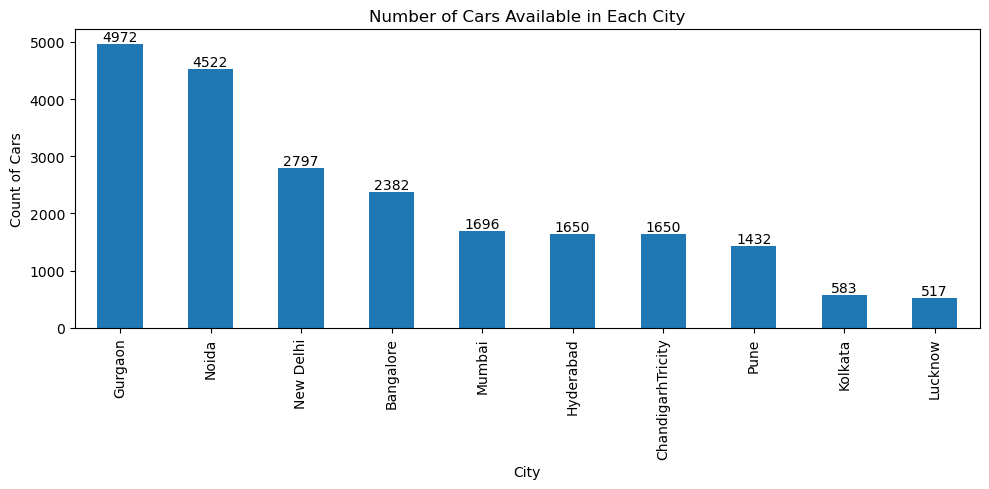

In [23]:
import matplotlib.pyplot as plt

ax = df_all["City"].value_counts().plot(kind="bar", figsize=(10,5))

# Add title and axis labels
plt.title("Number of Cars Available in Each City")
plt.xlabel("City")
plt.ylabel("Count of Cars")

# Add count labels on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

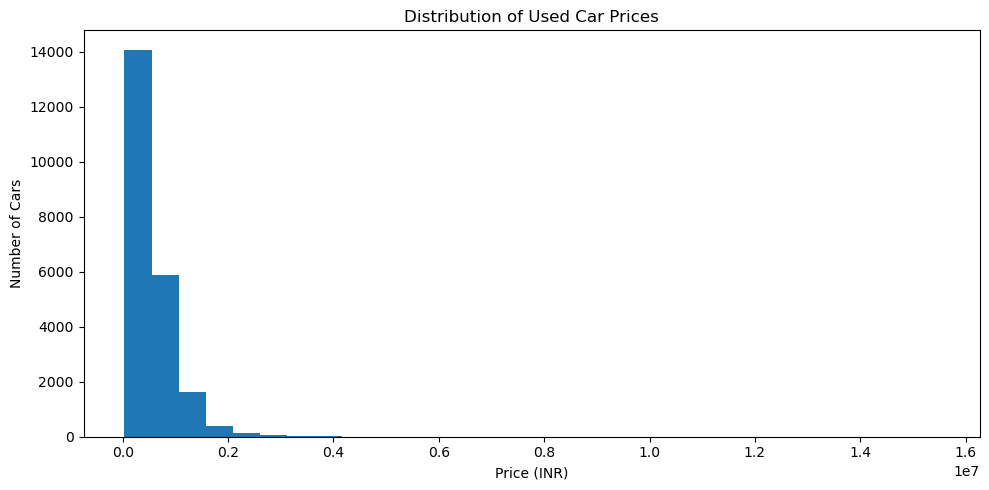

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_all["Price"], bins=30)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()


Outliers

In [19]:
Q1 = df_all["Price"].quantile(0.25)
Q3 = df_all["Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df_all[(df_all["Price"] < (Q1 - 1.5 * IQR)) |
                  (df_all["Price"] > (Q3 + 1.5 * IQR))]

outliers.head()

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
92,Toyota Innova Crysta,Toyota,2022,22173,Petrol,Auto,29349,1714000.0,4,Bangalore
94,Hyundai Creta N Line,Hyundai,2024,21118,Petrol,Auto,32588,1903000.0,2,Bangalore
103,Toyota Innova Crysta,Toyota,2020,74069,Diesel,Manual,35957,2100000.0,6,Bangalore
158,Toyota URBAN CRUISER HYRYDER,Toyota,2023,33241,Hybrid,Auto,24965,1458000.0,3,Bangalore
351,Mahindra XUV700,Mahindra,2022,69334,Diesel,Manual,26540,1550000.0,4,Bangalore


In [20]:
len(outliers)

1036

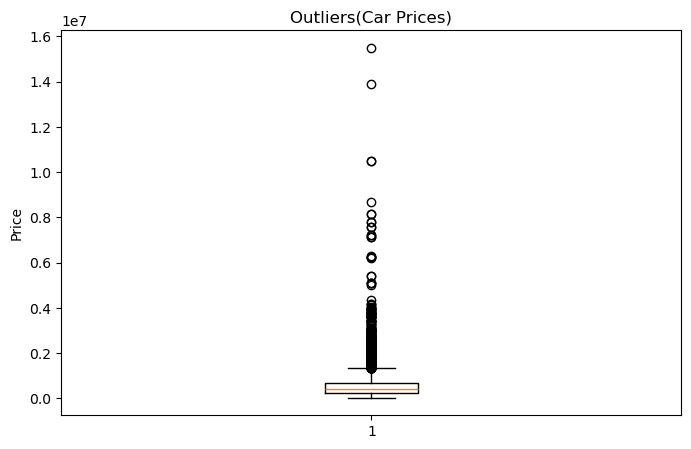

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df_all["Price"])
plt.title("Outliers(Car Prices)")
plt.ylabel("Price")
plt.show()

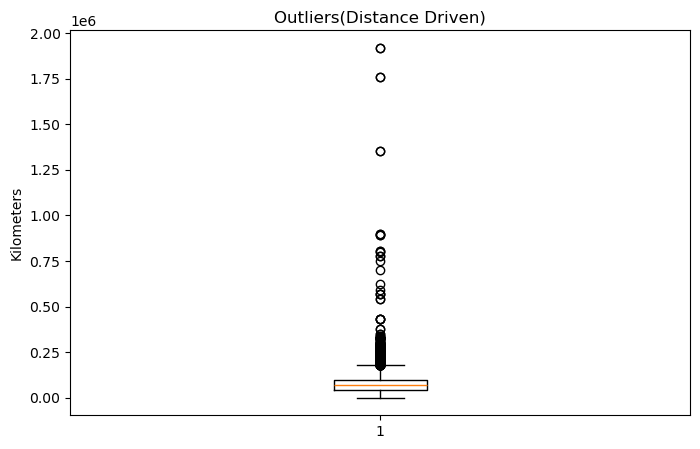

In [22]:
plt.figure(figsize=(8,5))
plt.boxplot(df_all["Distance Driven"])
plt.title("Outliers(Distance Driven)")
plt.ylabel("Kilometers")
plt.show()

In [25]:
df_all.sort_values("Distance Driven", ascending =False).head(20)[['Car Name', 'Company', 'Distance Driven', 'Price']]

,Car Name,Company,Distance Driven,Price
14860,MG HECTOR,MG,1920000,900000.0
16510,MG HECTOR,MG,1920000,900000.0
16857,MG HECTOR,MG,1760000,1150000.0
15207,MG HECTOR,MG,1760000,1150000.0
14627,Tata Indica Vista,Tata,1354000,90000.0
16277,Tata Indica Vista,Tata,1354000,90000.0
11267,Hyundai Creta,Hyundai,900001,552000.0
19376,Hyundai Creta,Hyundai,900001,552000.0
18872,Hyundai i10,Hyundai,892895,87000.0
10699,Hyundai i10,Hyundai,892895,87000.0


In [27]:
df_all= df_all[df_all["Distance Driven"] <= 500000]
df_all

,Car Name,Company,Year of Manufacture,Distance Driven,Fuel Type,Gear Type,EMI,Price,Car Age,City
0,Tata TIGOR,Tata,2021,36206,Petrol,Manual,10060,570000.0,5,Bangalore
1,Maruti Wagon R 1.0,Maruti,2017,43965,Petrol,Auto,7484,383000.0,9,Bangalore
2,Renault Kwid,Renault,2017,45145,Petrol,Manual,5645,289000.0,9,Bangalore
3,Maruti Wagon R 1.0,Maruti,2017,49218,Petrol,Auto,7147,366000.0,9,Bangalore
4,Volkswagen Ameo,Volkswagen,2016,67291,Petrol,Manual,9518,428000.0,10,Bangalore
...,...,...,...,...,...,...,...,...,...,...
22196,Toyota Fortuner,Toyota,2018,138526,Diesel,Manual,37614,1730000.0,8,Lucknow
22197,Tata PUNCH,Tata,2023,40387,Petrol,Manual,9929,562000.0,3,Lucknow
22198,Hyundai EXTER,Hyundai,2024,45532,Petrol,Manual,9974,565000.0,2,Lucknow
22199,Hyundai Grand i10,Hyundai,2018,95648,Petrol,Manual,5208,295000.0,8,Lucknow


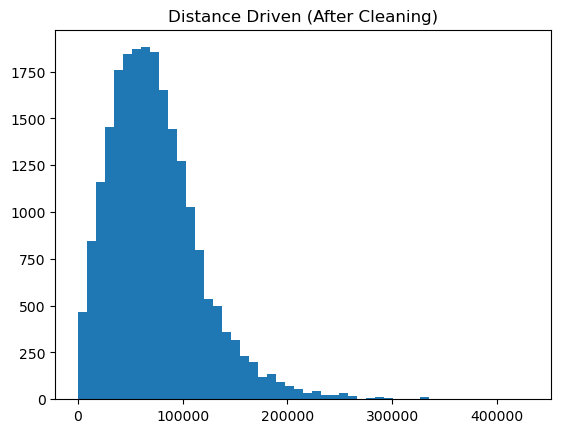

In [29]:
# km_driven after distribution 
plt.figure()
plt.hist(df_all["Distance Driven"], bins=50)
plt.title("Distance Driven (After Cleaning)")
plt.show()

In [30]:
df_all['Distance Driven'].max()

430000

In [31]:
df_all.sort_values("Distance Driven", ascending =False).head(20)[['Car Name', 'Company', 'Distance Driven', 'Price']]

,Car Name,Company,Distance Driven,Price
20975,Maruti Ciaz,Maruti,430000,484000.0
13109,Maruti Ciaz,Maruti,430000,484000.0
3300,Mahindra TUV300,Mahindra,430000,530000.0
8281,Maruti Ciaz,Maruti,430000,484000.0
8447,Toyota Innova Crysta,Toyota,375247,1029000.0
20979,Toyota Innova Crysta,Toyota,375247,1029000.0
5463,Tata Safari,Tata,352548,184000.0
3485,Hyundai i20 Active,Hyundai,350000,358000.0
19538,Mahindra MARAZZO,Mahindra,341397,375000.0
11441,Mahindra MARAZZO,Mahindra,341397,375000.0


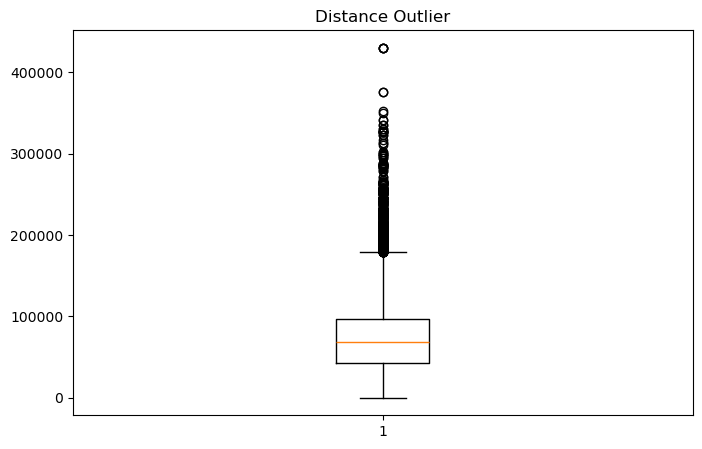

In [32]:
plt.figure(figsize = (8,5))
plt.boxplot(df_all['Distance Driven'])
plt.title("Distance Outlier")
plt.show()

In [40]:
df_all.to_csv('All_Cities_Cars24.csv',index=False)

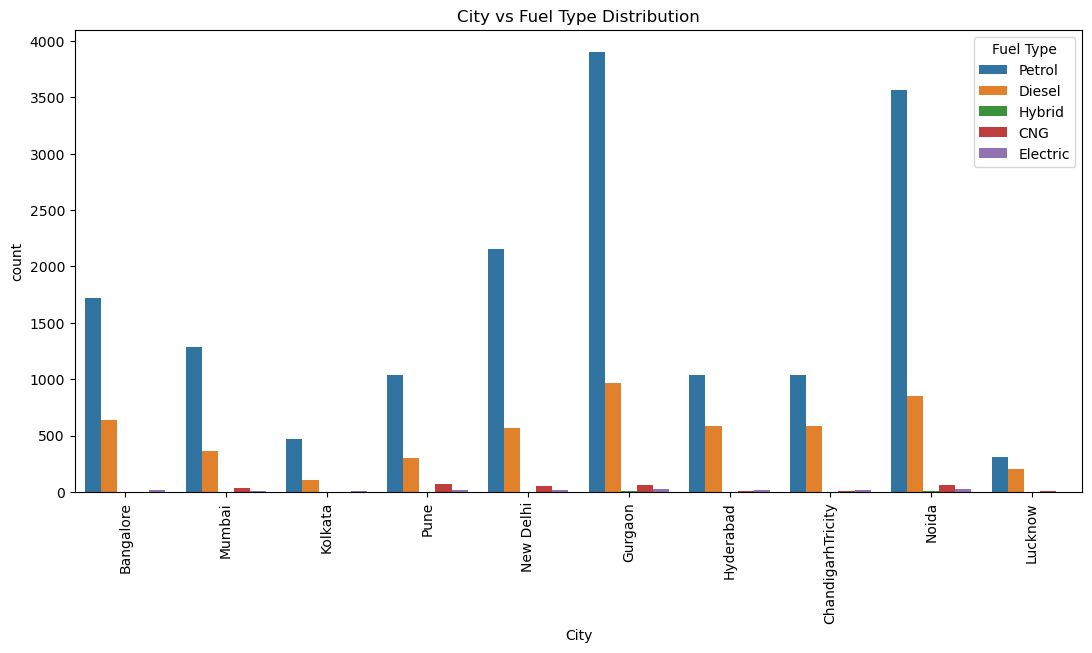

In [36]:
# City VS Fuel Type Distribution (CountPlot)
plt.figure(figsize=(13,6))
sns.countplot(data=df_all,x='City',hue='Fuel Type')
plt.title('City vs Fuel Type Distribution')
plt.xticks(rotation=90)
plt.show()

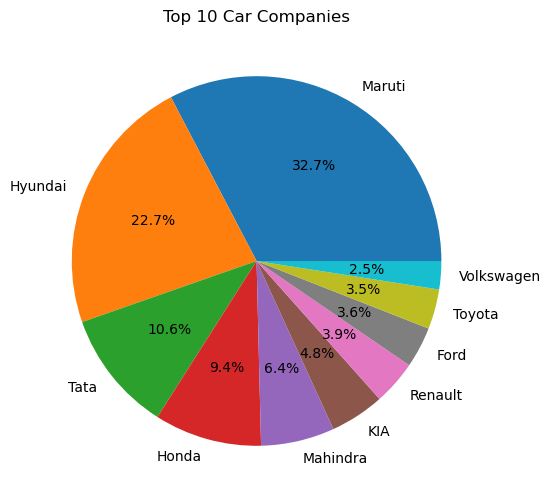

In [38]:
# Top 10 Car Companies (Based on Count of Cars)
top_companies = df_all['Company'].value_counts().head(10)

plt.figure(figsize=(6,6))
plt.pie(
    top_companies,
    labels=top_companies.index,
    autopct='%1.1f%%',
    startangle=0
)
plt.title('Top 10 Car Companies')
plt.show()

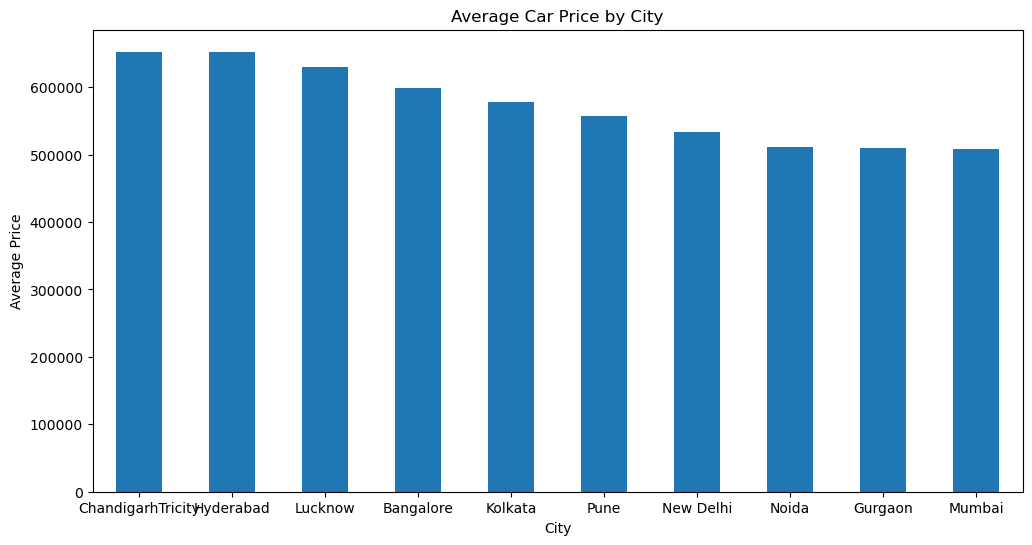

In [39]:
# Average Car Price by City 
avg_price = df_all.groupby('City')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')
plt.title('Average Car Price by City')
plt.xlabel('City')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.show()